# 04 — Feature Engineering
Phase 5: engineered, fraud-relevant features, all computable at claim-intake time (before any investigation outcome exists).

In [1]:
import sys
sys.path.append('../src')
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from preprocessing import load_raw_data, basic_clean, encode_target
from feature_engineering import engineer_features, ENGINEERED_FEATURE_NOTES

sns.set_theme(style='whitegrid')
RANDOM_STATE = 42

df = load_raw_data('../data/raw/insurance_claims.csv')
df = basic_clean(df); df = encode_target(df)
train_df, test_df = train_test_split(df, test_size=0.2, stratify=df['fraud_reported'], random_state=RANDOM_STATE)
train_df = train_df.reset_index(drop=True); test_df = test_df.reset_index(drop=True)

## Engineered features, with formula / business meaning / leakage check

| Feature | Formula | Business meaning | Why it could help | Leakage risk |
|---|---|---|---|---|
| `policy_tenure_days` | `incident_date - policy_bind_date` | Days on the books before the incident | Very short tenure + claim = classic premeditated-fraud pattern | None — both dates known at intake |
| `incident_hour_bucket` | binned `incident_hour_of_the_day` | Time-of-day category | Staged incidents may cluster at low-witness hours | None |
| `claim_to_premium_ratio` | `total_claim_amount / policy_annual_premium` | Claim size relative to what customer pays in | Disproportionate claims are a known informal red flag | None — claimed amount, not adjusted/confirmed amount |
| `injury_claim_share`, `property_claim_share`, `vehicle_claim_share` | component / `total_claim_amount` | How the claim is split | Skewed component shares can indicate exaggeration | None |
| `tenure_group` | binned `months_as_customer` | New / Established / Loyal | Simplifies tenure signal for interpretability | None |
| `low_witness_flag` | `witnesses == 0` | No independent witnesses | Established SIU heuristic | None |
| `no_report_flag` | `police_report_available != 'YES'` | No police report on file | Established SIU heuristic | None |
| `high_value_claim_flag` | `total_claim_amount > 75th pct(TRAIN)` | Top-quartile claim | Explicit high-value flag for simpler models | **Threshold must be fit on TRAIN only** — see below |
| `severity_vehicle_mismatch` | low severity + multiple parties + injuries claimed | Inconsistent reporting flag | Internal inconsistency can indicate exaggeration | None |

We deliberately did **not** engineer any feature from `fraud_reported` itself, investigator notes, or any field that would only be populated after a claim is confirmed/adjusted — those would leak the label into the features.

In [2]:
train_fe, high_value_threshold = engineer_features(train_df)
test_fe, _ = engineer_features(test_df, high_value_threshold=high_value_threshold)

print(f"75th-percentile claim threshold learned on TRAIN: ${high_value_threshold:,.2f}")
print(f"Applied unchanged to TEST — this is the leakage-safe pattern.")
new_cols = ['policy_tenure_days','incident_hour_bucket','claim_to_premium_ratio',
            'injury_claim_share','property_claim_share','vehicle_claim_share',
            'tenure_group','low_witness_flag','no_report_flag','high_value_claim_flag',
            'severity_vehicle_mismatch']
train_fe[new_cols].head()

75th-percentile claim threshold learned on TRAIN: $70,425.00
Applied unchanged to TEST — this is the leakage-safe pattern.


,policy_tenure_days,incident_hour_bucket,claim_to_premium_ratio,injury_claim_share,property_claim_share,vehicle_claim_share,tenure_group,low_witness_flag,no_report_flag,high_value_claim_flag,severity_vehicle_mismatch
0,2031,Late Night,5.038220,0.100000,0.100000,0.800000,Loyal (5yr+),1,1,0,0
1,8444,Morning,44.426946,0.083333,0.166667,0.750000,Loyal (5yr+),0,1,0,0
2,9097,Morning,47.901439,0.181818,0.090909,0.727273,Loyal (5yr+),0,1,1,0
3,4282,Late Night,52.130670,0.090909,0.181818,0.727273,New (<1yr),1,1,0,0
4,3131,Evening,36.677909,0.000000,0.111111,0.888889,Loyal (5yr+),0,1,0,0


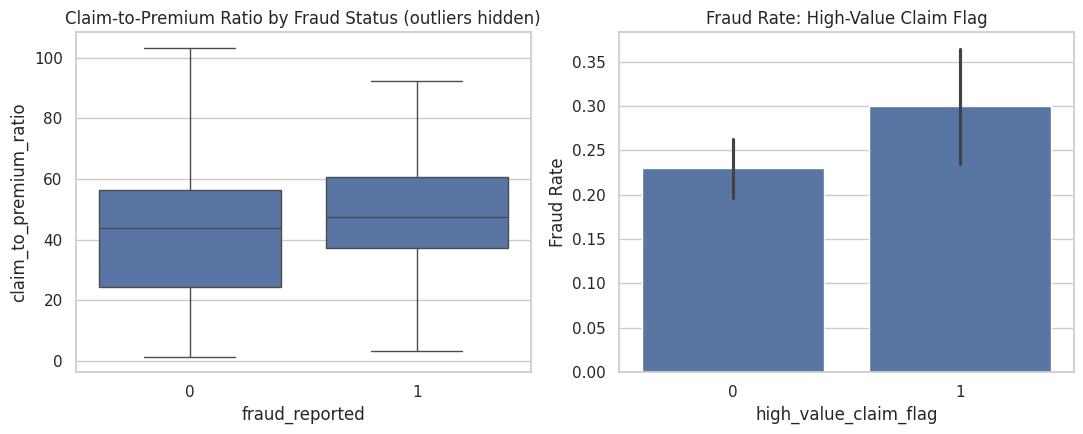

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11,4.5))
sns.boxplot(x='fraud_reported', y='claim_to_premium_ratio', data=train_fe, ax=axes[0], showfliers=False)
axes[0].set_title('Claim-to-Premium Ratio by Fraud Status (outliers hidden)')
sns.barplot(x='high_value_claim_flag', y='fraud_reported', data=train_fe, ax=axes[1])
axes[1].set_title('Fraud Rate: High-Value Claim Flag')
axes[1].set_ylabel('Fraud Rate')
plt.tight_layout(); plt.show()

**Observation:** claims flagged as high-value (top quartile) show a modestly higher fraud rate than the rest of the training set, consistent with the EDA finding on claim amount. `claim_to_premium_ratio` shows overlapping but shifted distributions between fraud and non-fraud claims.

**Business interpretation:** these engineered features operationalize informal investigator heuristics into explicit, consistent, always-computed model inputs — useful both for model performance and for producing intuitive, explainable "key risk factors" per claim in the Phase 10 scoring table.

**Correlation vs. causation:** as with the raw EDA, these are associations in the training sample, not proof that a high claim-to-premium ratio *causes* or *proves* fraud on any individual claim.

In [4]:
train_fe.to_csv('../data/processed/train_engineered_demo.csv', index=False)
test_fe.to_csv('../data/processed/test_engineered_demo.csv', index=False)
print("Saved engineered train/test sets.")
print("Final engineered feature count (pre-encoding):", train_fe.shape[1])

Saved engineered train/test sets.
Final engineered feature count (pre-encoding): 50


## Phase 5 summary
11 new features were engineered, each traceable to a specific, intake-time-available data source, each with an explicit leakage assessment, and one (`high_value_claim_flag`) implemented carefully so its threshold is learned only from the training split. These features are passed into the same `ColumnTransformer` from notebook 03 before modeling in notebook 05.